In [1]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [2]:
limit = 30
skip = 0
total = 0
page = 0
listpd = []
while True:
    url = f'https://dummyjson.com/users?limit={limit}&skip={skip}'
    response = requests.get(url)
    data = response.json()['users']
    listpd.append(pd.DataFrame(data))
    total = response.json()["total"]
    skip += limit
    if skip >= total:   # all data extracted
        break
    print(page)  
    page += 1


0
1
2
3
4
5


In [3]:
users = pd.concat(listpd)
print(users)

     id firstName  lastName maidenName  age  gender  \
0     1     Emily   Johnson      Smith   29  female   
1     2   Michael  Williams              36    male   
2     3    Sophia     Brown              43  female   
3     4     James     Davis              46    male   
4     5      Emma    Miller    Johnson   31  female   
..  ...       ...       ...        ...  ...     ...   
23  204     Mateo     Perez              46    male   
24  205    Aubrey    Garcia       Gray   29  female   
25  206     Elena     Baker              35  female   
26  207      Jace     Smith              42    male   
27  208  Samantha  Martinez      Lopez   28  female   

                                email             phone   username  \
0       emily.johnson@x.dummyjson.com  +81 965-431-3024     emilys   
1    michael.williams@x.dummyjson.com  +49 258-627-6644   michaelw   
2        sophia.brown@x.dummyjson.com  +81 210-652-2785    sophiab   
3         james.davis@x.dummyjson.com  +49 614-958-9364    

In [4]:
users.to_csv("users.csv", index=False)

In [5]:
df = pd.read_csv("users.csv")
df.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,NaN,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,NaN,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,NaN,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


In [6]:
df.shape

(208, 28)

In [7]:
df.columns

Index(['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email',
       'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup',
       'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role'],
      dtype='object')

In [8]:
df.dtypes

id              int64
firstName      object
lastName       object
maidenName     object
age             int64
gender         object
email          object
phone          object
username       object
password       object
birthDate      object
image          object
bloodGroup     object
height        float64
weight        float64
eyeColor       object
hair           object
ip             object
address        object
macAddress     object
university     object
bank           object
company        object
ein            object
ssn            object
userAgent      object
crypto         object
role           object
dtype: object

In [9]:
df.isnull().sum()

id              0
firstName       0
lastName        0
maidenName    148
age             0
gender          0
email           0
phone           0
username        0
password        0
birthDate       0
image           0
bloodGroup      0
height          0
weight          0
eyeColor        0
hair            0
ip              0
address         0
macAddress      0
university      0
bank            0
company         0
ein             0
ssn             0
userAgent       0
crypto          0
role            0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.describe()

,id,age,height,weight
count,208.000000,208.000000,208.000000,208.000000
mean,104.500000,33.139423,175.720240,75.038606
std,60.188592,5.544269,14.119984,14.090775
min,1.000000,23.000000,150.250000,50.100000
25%,52.750000,29.000000,164.187500,62.547500
50%,104.500000,32.000000,177.430000,75.985000
75%,156.250000,36.000000,186.960000,86.992500
max,208.000000,46.000000,199.810000,99.540000


In [13]:
df['gender'].value_counts()

gender
female    106
male      102
Name: count, dtype: int64

In [14]:
df['bloodGroup'].value_counts()

bloodGroup
O-     31
B-     31
AB+    29
AB-    29
B+     25
O+     22
A+     21
A-     20
Name: count, dtype: int64

In [15]:
df['eyeColor'].value_counts()

eyeColor
Brown     35
Hazel     34
Green     28
Blue      24
Gray      24
Violet    22
Red       21
Amber     20
Name: count, dtype: int64

In [16]:
df['role'].value_counts()

role
user         193
moderator     10
admin          5
Name: count, dtype: int64

In [20]:
def parse_address(addr):
    try:
        addr_dict = json.loads(addr.replace("'", '"'))
        return addr_dict
    except:
        return {}

In [22]:
df['country'] = df['address'].apply(lambda x: parse_address(x).get('country'))
df['city'] = df['address'].apply(lambda x: parse_address(x).get('city'))
df['state'] = df['address'].apply(lambda x: parse_address(x).get('state'))
df['postalCode'] = df['address'].apply(lambda x: parse_address(x).get('postalCode'))

In [23]:
df['country'].value_counts()

country
United States    208
Name: count, dtype: int64

In [26]:
df['maidenName'].fillna('Unknown', inplace=True)

In [28]:
df['maidenName'].isnull().sum()

0

In [29]:
avg_age = df['age'].mean()
avg_age

33.13942307692308

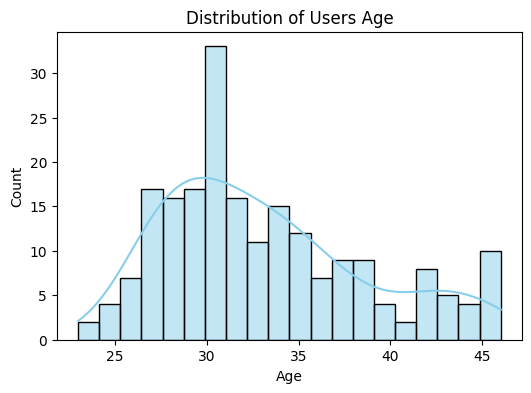

In [43]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Users Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [30]:
avg_age_gender = df.groupby('gender')['age'].mean()
avg_age_gender

gender
female    31.377358
male      34.970588
Name: age, dtype: float64

D:\Temp\ipykernel_14288\2986931609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_age_gender.index, y=avg_age_gender.values, palette='pastel')


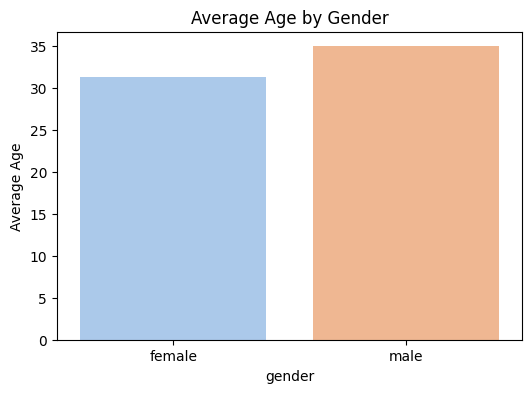

In [45]:
plt.figure(figsize=(6,4))
sns.barplot(x=avg_age_gender.index, y=avg_age_gender.values, palette='pastel')
plt.title('Average Age by Gender')
plt.ylabel('Average Age')
plt.show()

In [33]:
user_per_gender = df['gender'].value_counts()
user_per_gender

gender
female    106
male      102
Name: count, dtype: int64

D:\Temp\ipykernel_14288\1869561246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', palette='Set2')


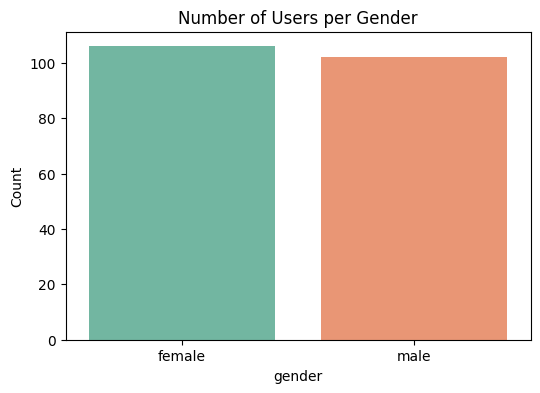

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', palette='Set2')
plt.title('Number of Users per Gender')
plt.ylabel('Count')
plt.show()

In [36]:
top_cities = df['city'].value_counts().head(10)
top_cities

city
Phoenix         17
Dallas          15
Jacksonville    14
Los Angeles     14
Seattle         12
San Jose        11
Charlotte       11
Philadelphia    11
Chicago         11
Columbus        11
Name: count, dtype: int64

D:\Temp\ipykernel_14288\2524908908.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='magma')


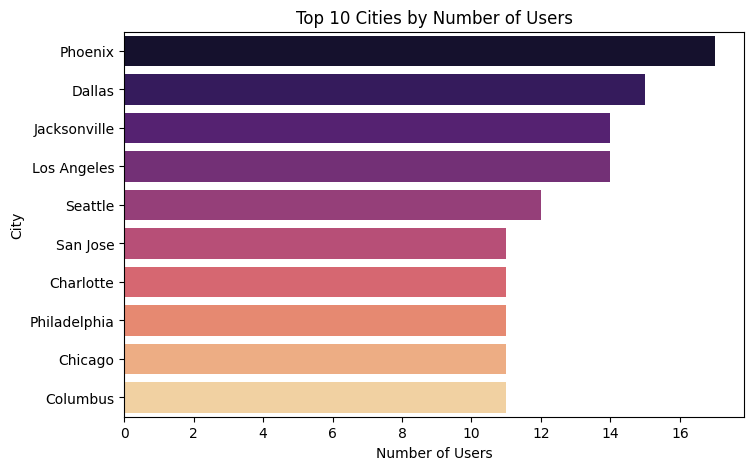

In [47]:
plt.figure(figsize=(8,5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='magma')
plt.title('Top 10 Cities by Number of Users')
plt.xlabel('Number of Users')
plt.ylabel('City')
plt.show()

In [37]:
avg_height = df['height'].mean()
avg_weight = df['weight'].mean()
print(avg_height)
print(avg_weight)

175.72024038461538
75.03860576923077


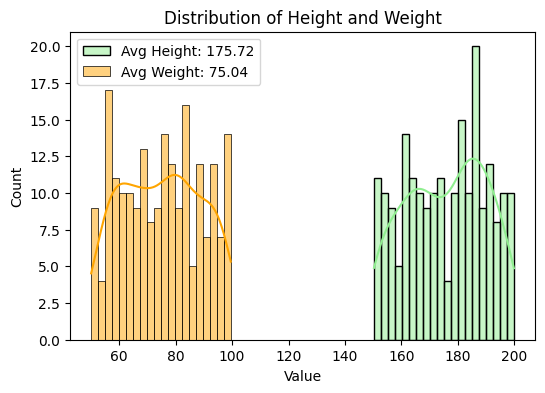

In [48]:
plt.figure(figsize=(6,4))
sns.histplot(df['height'], bins=20, color='lightgreen', kde=True, label=f'Avg Height: {avg_height:.2f}')
sns.histplot(df['weight'], bins=20, color='orange', kde=True, label=f'Avg Weight: {avg_weight:.2f}')
plt.title('Distribution of Height and Weight')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.show()

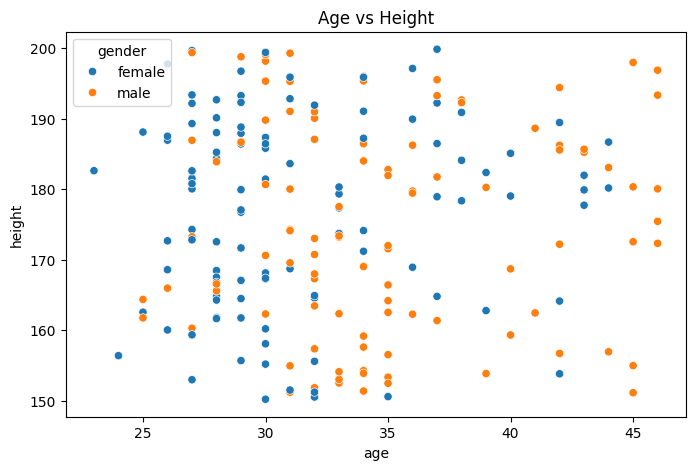

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data = df, x ='age', y ='height', hue ='gender')
plt.title('Age vs Height')
plt.show()

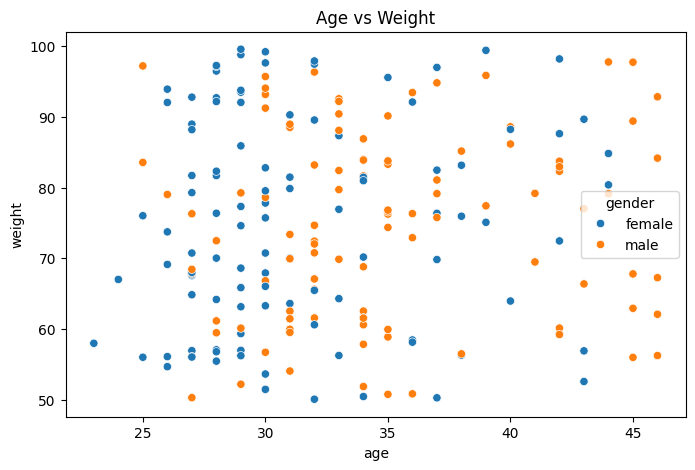

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(data = df, x ='age', y ='weight', hue ='gender')
plt.title('Age vs Weight')
plt.show()